In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [129]:
testdf= pd.read_csv("test_energy_data.csv")
traindf = pd.read_csv("train_energy_data.csv")

In [130]:
df = pd.concat([testdf, traindf], ignore_index=True)

In [131]:
df.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,24563,15,4,28.52,Weekday,2865.57
1,Commercial,27583,56,23,23.07,Weekend,4283.80
2,Commercial,45313,4,44,33.56,Weekday,5067.83
3,Residential,41625,84,17,27.39,Weekend,4624.30
4,Residential,36720,58,47,17.08,Weekday,4820.59


In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1100 non-null   object 
 1   Square Footage       1100 non-null   int64  
 2   Number of Occupants  1100 non-null   int64  
 3   Appliances Used      1100 non-null   int64  
 4   Average Temperature  1100 non-null   float64
 5   Day of Week          1100 non-null   object 
 6   Energy Consumption   1100 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 60.3+ KB


In [133]:
# data is clear for the analyze

In [134]:
df.describe()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,25500.527273,48.268182,25.730000,22.559745,4168.191273
std,14236.955632,29.127624,14.116209,7.122357,924.278723
min,560.000000,1.000000,1.000000,10.050000,1683.950000
25%,13203.750000,22.000000,13.000000,16.365000,3510.460000
50%,25785.500000,47.000000,26.000000,22.810000,4189.690000
75%,37536.750000,73.000000,38.000000,28.760000,4859.510000
max,49997.000000,99.000000,49.000000,34.990000,6530.600000


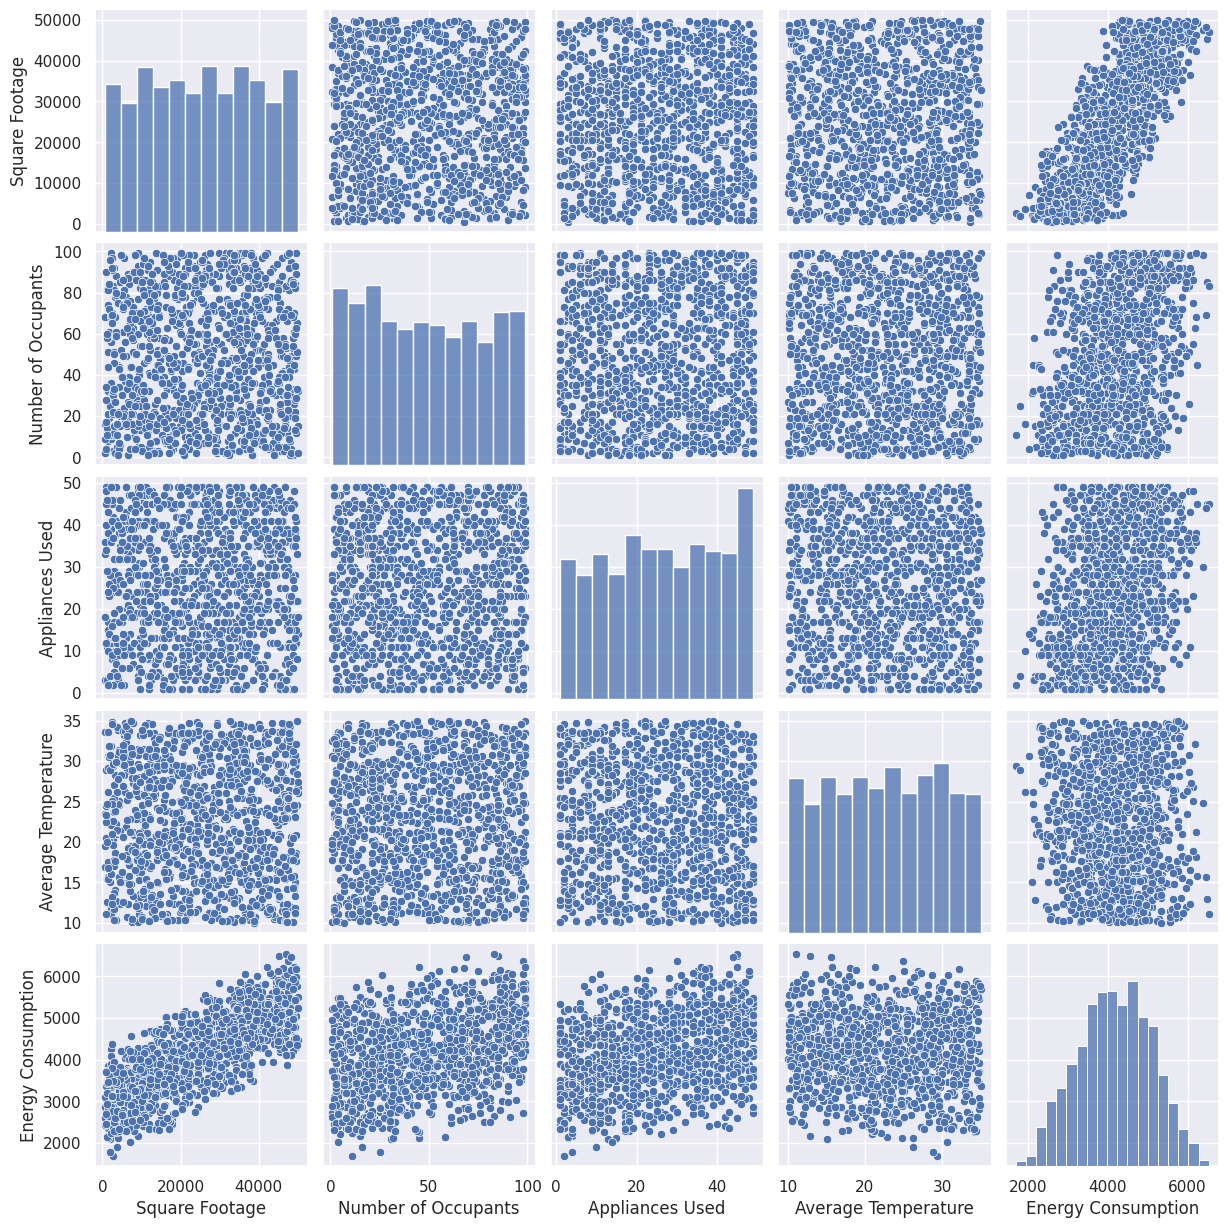

In [135]:
sns.pairplot(df)

In [136]:
sns.set_theme()

/tmp/ipykernel_5829/3096703653.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='Building Type', y='Energy Consumption', data=df, ax=axes[0][0],palette="tab10")
/tmp/ipykernel_5829/3096703653.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='Day of Week', y='Energy Consumption', data=df, ax=axes[0][1],palette="tab10")


Text(0.5, 1.0, 'Energy Consumption vs Appliances Used')

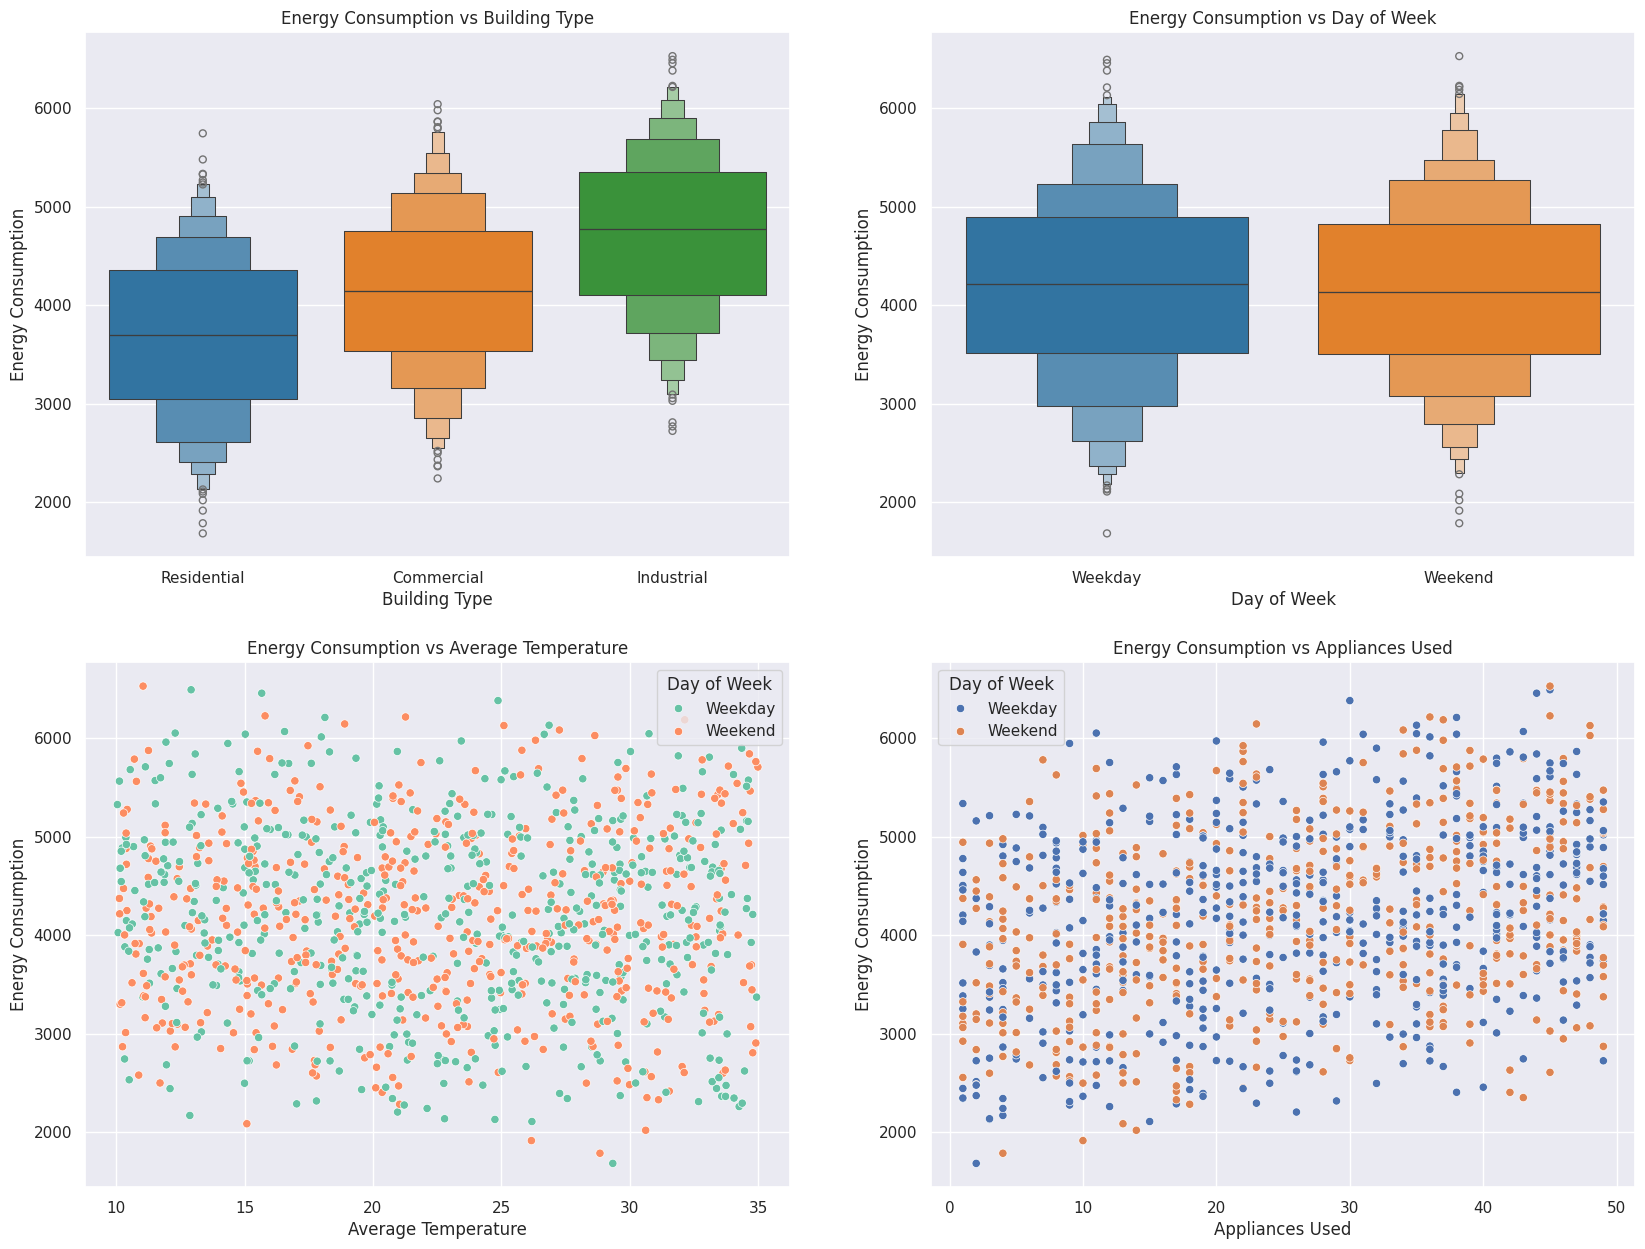

In [137]:
fig, axes = plt.subplots(2,2, figsize=(20, 15))
sns.boxenplot(x='Building Type', y='Energy Consumption', data=df, ax=axes[0][0],palette="tab10")
axes[0][0].set_title('Energy Consumption vs Building Type')
sns.boxenplot(x='Day of Week', y='Energy Consumption', data=df, ax=axes[0][1],palette="tab10")
axes[0][1].set_title('Energy Consumption vs Day of Week')
sns.scatterplot(x='Average Temperature', y='Energy Consumption',hue="Day of Week", data=df, ax=axes[1][0],palette="Set2")
axes[1][0].set_title('Energy Consumption vs Average Temperature')
sns.scatterplot(x='Appliances Used', y='Energy Consumption',hue="Day of Week", data=df, ax=axes[1][1])
axes[1][1].set_title('Energy Consumption vs Appliances Used')

In [138]:
df.columns

Index(['Building Type', 'Square Footage', 'Number of Occupants',
       'Appliances Used', 'Average Temperature', 'Day of Week',
       'Energy Consumption'],
      dtype='object')

/tmp/ipykernel_5829/2360484698.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Building Type",data=df,ax=axes[0],palette="tab10")
/tmp/ipykernel_5829/2360484698.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Day of Week",data=df,ax=axes[1],palette="tab10")


Text(0.5, 1.0, 'Day of Week')

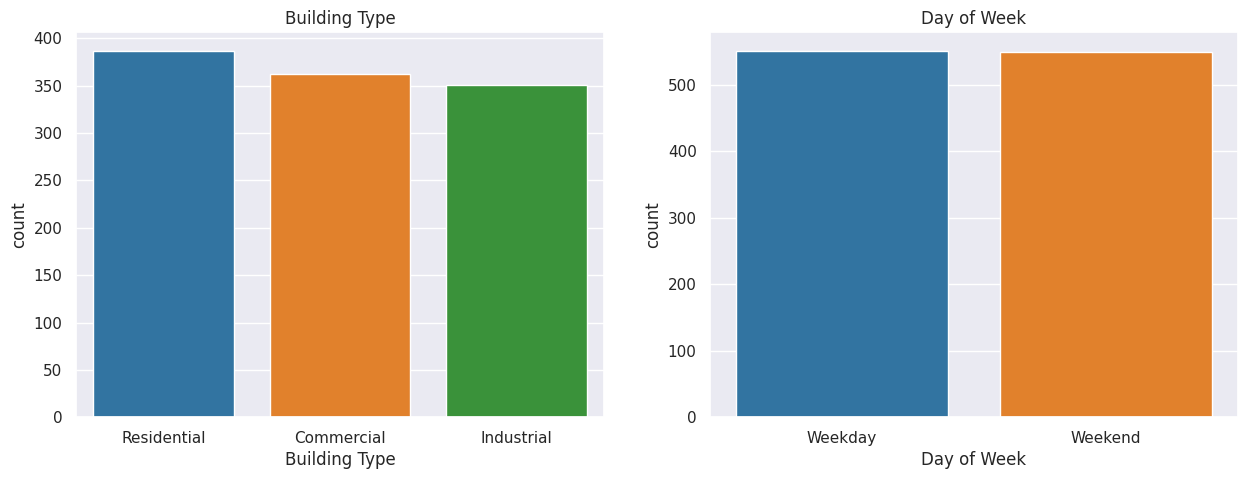

In [139]:
fig,axes = plt.subplots(1,2,figsize=(15,5))
sns.countplot(x="Building Type",data=df,ax=axes[0],palette="tab10")
axes[0].set_title("Building Type")
sns.countplot(x="Day of Week",data=df,ax=axes[1],palette="tab10")
axes[1].set_title("Day of Week")

Text(0.5, 1.0, 'Energy Consumption vs Appliances Used')

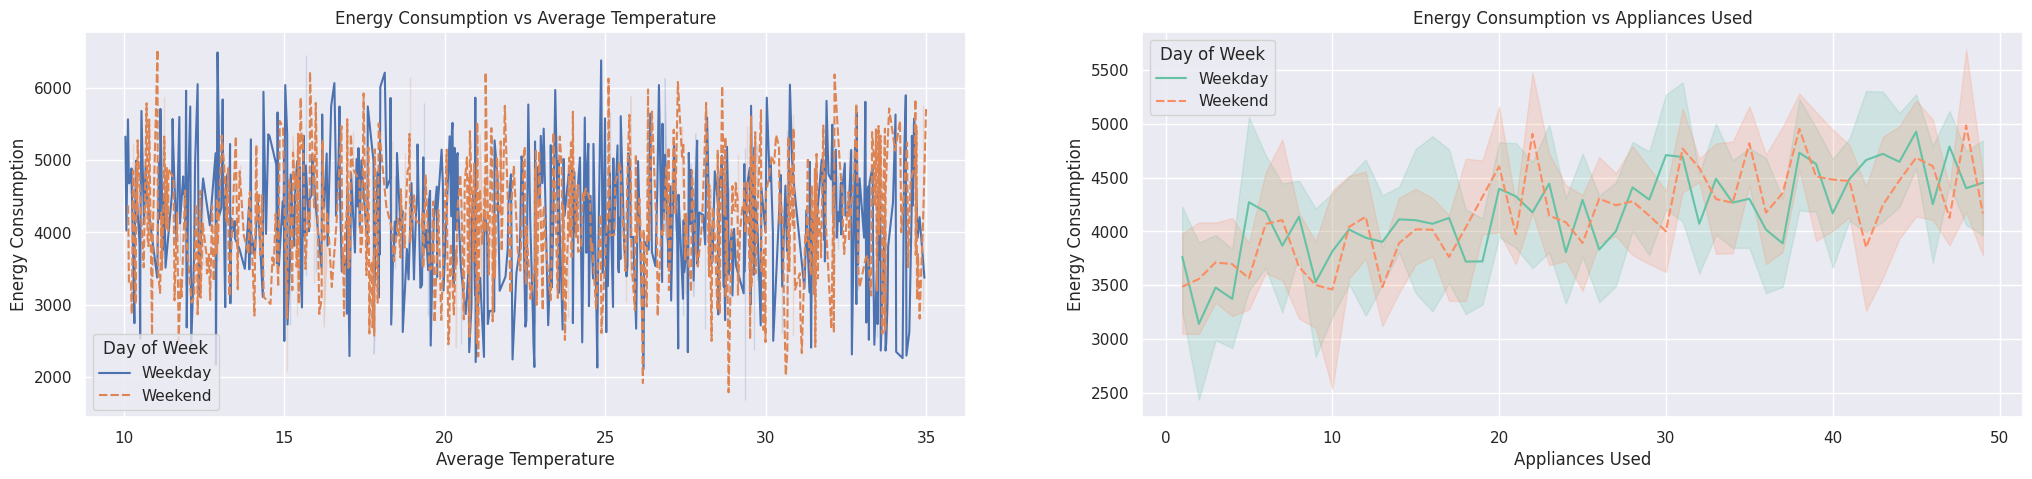

In [140]:
fig, axes = plt.subplots(1,2, figsize=(25, 5))
sns.lineplot(x='Average Temperature', y='Energy Consumption', data=df, ax=axes[0],hue='Day of Week',style='Day of Week')
axes[0].set_title("Energy Consumption vs Average Temperature")
sns.lineplot(x='Appliances Used', y='Energy Consumption', data=df, ax=axes[1],hue='Day of Week',style='Day of Week',palette="Set2")
axes[1].set_title("Energy Consumption vs Appliances Used")

In [141]:
df['Day of Week'].unique()

array(['Weekday', 'Weekend'], dtype=object)

In [142]:
df["Day of Week"].value_counts()

,count
Day of Week,
Weekday,551
Weekend,549


In [143]:
df.groupby("Day of Week")["Energy Consumption"].sum()

,Energy Consumption
Day of Week,
Weekday,2305557.41
Weekend,2279452.99


In [144]:
dfcorr = df.drop(columns=['Day of Week','Building Type'])

<Axes: >

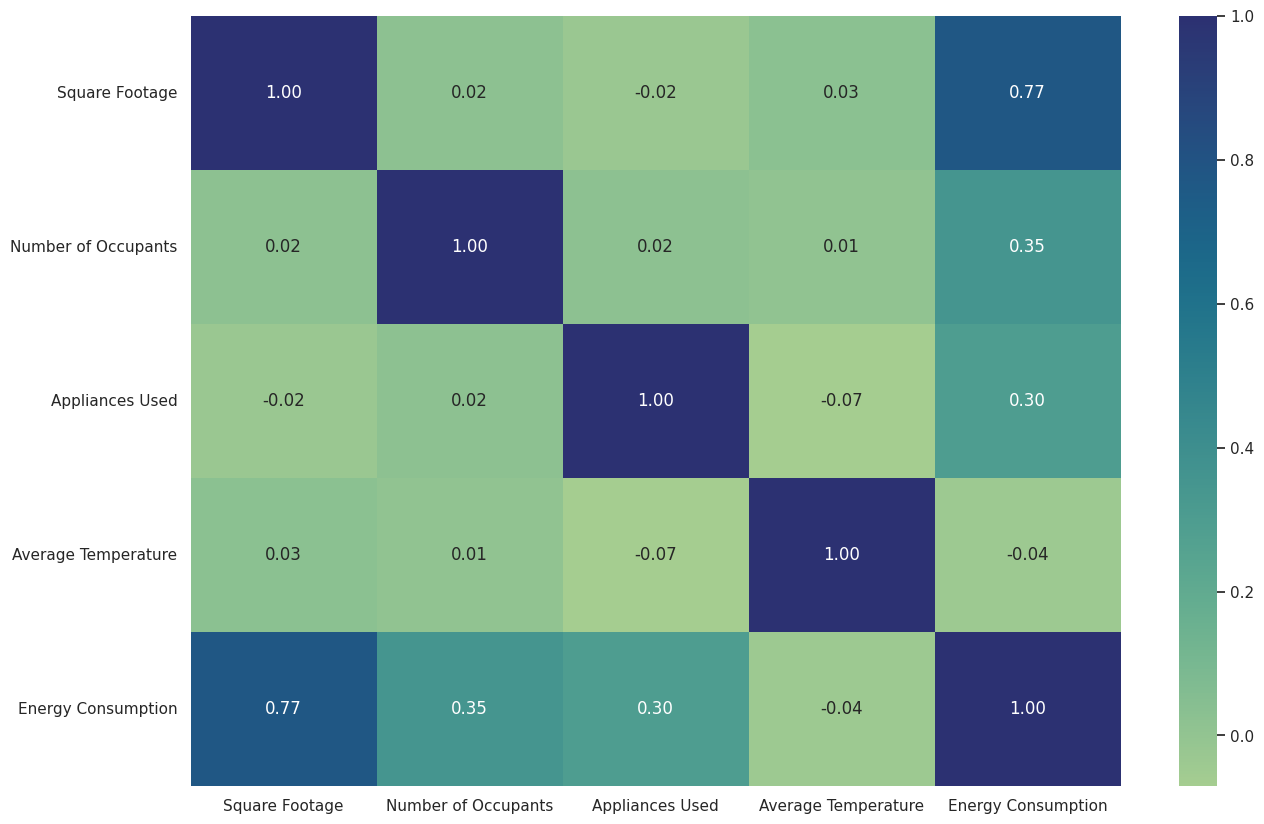

In [145]:
fig,axes = plt.subplots(figsize=(15,10))
sns.heatmap(dfcorr.corr(),annot=True,cmap="crest",fmt=".2f")

In [146]:
df.groupby("Building Type")["Energy Consumption"].sum()

,Energy Consumption
Building Type,
Commercial,1503293.82
Industrial,1655440.50
Residential,1426276.08


In [147]:
df = pd.get_dummies(df, columns=["Day of Week", "Building Type"], drop_first=True)

In [148]:
df.head()

,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption,Day of Week_Weekend,Building Type_Industrial,Building Type_Residential
0,24563,15,4,28.52,2865.57,False,False,True
1,27583,56,23,23.07,4283.80,True,False,False
2,45313,4,44,33.56,5067.83,False,False,False
3,41625,84,17,27.39,4624.30,True,False,True
4,36720,58,47,17.08,4820.59,False,False,True


In [149]:
from sklearn.model_selection import train_test_split

In [150]:
from sklearn.linear_model import LinearRegression

In [151]:
X=df.drop(columns=['Energy Consumption'])
y=df['Energy Consumption']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [152]:
model1=LinearRegression()

In [196]:
model1.fit(X_train,y_train)

LinearRegression()

In [197]:
y_pred_train1 = model1.predict(X_train)
y_pred_test1 = model1.predict(X_test)

In [198]:
from sklearn.metrics import r2_score ,mean_squared_error,mean_absolute_error

In [199]:
r2 = r2_score(y_train,y_pred_train1)
mse = mean_squared_error(y_train,y_pred_train1)
mae = mean_absolute_error(y_train,y_pred_train1)

In [200]:
print("R2 Score: ",r2)
print("MSE: ",mse)
print("MAE: ",mae)

R2 Score:  0.9999999997809788
MSE:  0.0001884503222133644
MAE:  0.011810087179667817


In [201]:
r2 = r2_score(y_test,y_pred_test1)
rmse = mean_squared_error(y_test,y_pred_test1)
mae = mean_absolute_error(y_test,y_pred_test1)

In [202]:
print("R2 Score: ",r2)
print("RMSE: ",rmse)
print("MAE: ",mae)

R2 Score:  0.9999999997744795
RMSE:  0.00018778899777191564
MAE:  0.011506658660658683


In [160]:
# overfiting gözükmüyor farklı modellerle de deniyelim R'2 scorunu yükseltmek için

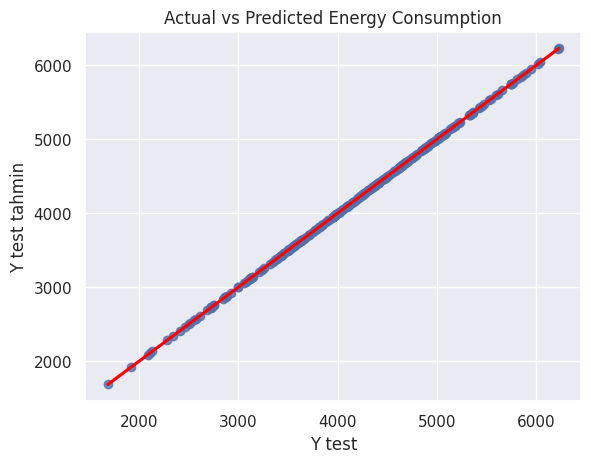

In [161]:
sns.regplot(x=y_test, y=y_pred_test1, line_kws={'color': 'red'})
plt.xlabel("Y test")
plt.ylabel("Y test tahmin")
plt.title("Actual vs Predicted Energy Consumption")
plt.show()

In [162]:
from sklearn.preprocessing import StandardScaler

In [163]:
scaler = StandardScaler()

In [164]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [165]:
model_scaled = LinearRegression()
model_scaled.fit(X_train_scaled, y_train)

LinearRegression()

In [166]:
y_pred_train_scaled= model_scaled.predict(X_train_scaled)
y_pred_test_scaled = model_scaled.predict(X_test_scaled)

In [167]:
R2_train_scaled = r2_score(y_train, y_pred_train_scaled)
R2_test_scaled = r2_score(y_test, y_pred_test_scaled)

print(" R2 Score Train (Scaled Data): ", R2_train_scaled)
print(" R2 Score Test (Scaled Data): ", R2_test_scaled)

 R2 Score Train (Scaled Data):  0.9999999997809788
 R2 Score Test (Scaled Data):  0.9999999997744795


In [168]:
from sklearn.neighbors import KNeighborsRegressor

In [169]:
regressor = KNeighborsRegressor()

In [170]:
regressor.fit(X_train_scaled,y_train)

KNeighborsRegressor()

In [171]:
y_predknn = regressor.predict(X_test_scaled)

In [172]:
print("R2 Score: ",r2_score(y_test,y_predknn))

R2 Score:  0.9432774512952397


In [173]:
print("MSE: ",mean_squared_error(y_test,y_predknn))

MSE:  47232.38160494544


In [174]:
# R^2 scorumuzz linear modele göre daha sağlıklı

In [175]:
# SVR

In [176]:
from sklearn.svm import SVR

In [177]:
svr = SVR()

In [178]:
svr.fit(X_train_scaled,y_train)

SVR()

In [179]:
y_predsvr = svr.predict(X_test_scaled)

In [180]:
print("R2 Score: ",r2_score(y_test,y_predsvr))

R2 Score:  0.07232944656768625


In [181]:
# HYPER PARAMETRE TUNİG

In [182]:
param_grid={'C':[0.1,1],'gamma':[1,0.1],"kernel":["rbf","linear"]}


In [183]:
from sklearn.model_selection import GridSearchCV

In [184]:
grid = GridSearchCV(SVR(),param_grid=param_grid,verbose=3,n_jobs=-1)

In [185]:
grid.fit(X_train_scaled,y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(estimator=SVR(), n_jobs=-1,
             param_grid={'C': [0.1, 1], 'gamma': [1, 0.1],
                         'kernel': ['rbf', 'linear']},
             verbose=3)

In [186]:
grid.best_params_

{'C': 1, 'gamma': 1, 'kernel': 'linear'}

In [187]:
y_predgridsvr = grid.predict(X_test_scaled)

In [188]:
print("R2 Score: ",r2_score(y_test,y_predgridsvr))
print("MSE: ",mean_squared_error(y_test,y_predgridsvr))

R2 Score:  0.9559863863758455
MSE:  36649.7599628175


In [189]:
param_grid2={'C':[0.1,1,10,100],'gamma':[1,0.1,0.01],"kernel":["rbf","linear"]}

In [190]:
grid = GridSearchCV(SVR(),param_grid=param_grid2,verbose=3,n_jobs=-1)

In [191]:
grid.fit(X_train_scaled,y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(estimator=SVR(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01],
                         'kernel': ['rbf', 'linear']},
             verbose=3)

In [192]:
grid.best_params_

{'C': 100, 'gamma': 1, 'kernel': 'linear'}

In [193]:
y_predgridsvr2 = grid.predict(X_test_scaled)

In [194]:
print("R2 score",r2_score(y_test,y_predgridsvr2))
print("MSE",mean_squared_error(y_test,y_predgridsvr2))

R2 score 0.9999999974758117
MSE 0.002101870005551789


In [195]:
# daha da arttı

In [204]:
from sklearn.tree import DecisionTreeRegressor

In [284]:
tree_model = DecisionTreeRegressor()

In [285]:
tree_model.fit(X_train_scaled,y_train)

DecisionTreeRegressor()

In [286]:
y_predtesttree = tree_model.predict(X_test_scaled)

In [287]:
print("R2 score",r2_score(y_test,y_predtesttree))
print("MSE",mean_squared_error(y_test,y_predtesttree))

R2 score 0.9293005625762726
MSE 58870.8174069091


In [226]:
from sklearn import tree

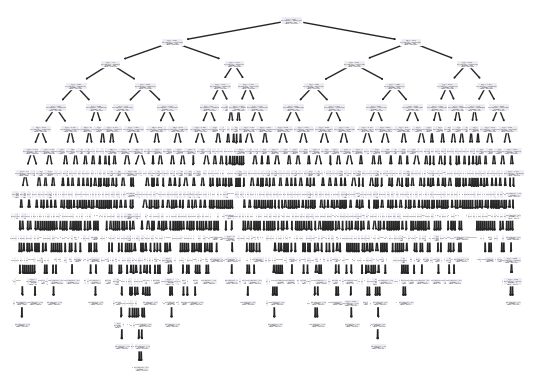

In [289]:
tree.plot_tree(tree_model.fit(X_train_scaled,y_train));

In [ ]:
# HYPER PARAMETRE TUNING

In [276]:
param = {"criterion":["squared_error", "friedman_mse", "absolute_error", "poisson"],"splitter": ["best", "random"], "max_depth": [1,2,3,4],
         "max_features":["sqrt","log2",None]}

In [246]:
import warnings

In [277]:
gridtree = GridSearchCV(DecisionTreeRegressor(),param_grid=param)

In [278]:
warnings.filterwarnings("ignore")

In [279]:
gridtree.fit(X_train_scaled,y_train)

GridSearchCV(estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error', 'poisson'],
                         'max_depth': [1, 2, 3, 4],
                         'max_features': ['sqrt', 'log2', None],
                         'splitter': ['best', 'random']})

In [280]:
gridtree.best_params_

{'criterion': 'poisson',
 'max_depth': 4,
 'max_features': None,
 'splitter': 'best'}

In [281]:
y_predtreegrid = gridtree.predict(X_test_scaled)

In [282]:
print("R2 score", r2_score(y_test,y_predtreegrid))
print("MSE", mean_squared_error(y_test,y_predtreegrid))

R2 score 0.7904059516112535
MSE 174527.1730850816


[Text(0.5, 0.9, 'Square Footage <= -0.205\npoisson = 105.657\nsamples = 825\nvalue = 4165.227'),
 Text(0.25, 0.7, 'Building Type_Residential <= 0.351\npoisson = 65.014\nsamples = 371\nvalue = 3471.379'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'Number of Occupants <= 0.158\npoisson = 48.001\nsamples = 256\nvalue = 3701.577'),
 Text(0.0625, 0.3, 'Square Footage <= -1.302\npoisson = 36.629\nsamples = 148\nvalue = 3439.176'),
 Text(0.03125, 0.1, 'poisson = 33.94\nsamples = 43\nvalue = 3019.663'),
 Text(0.09375, 0.1, 'poisson = 22.576\nsamples = 105\nvalue = 3610.977'),
 Text(0.1875, 0.3, 'Square Footage <= -0.813\npoisson = 33.601\nsamples = 108\nvalue = 4061.162'),
 Text(0.15625, 0.1, 'poisson = 25.253\nsamples = 64\nvalue = 3804.666'),
 Text(0.21875, 0.1, 'poisson = 17.072\nsamples = 44\nvalue = 4434.247'),
 Text(0.375, 0.5, 'Number of Occupants <= -0.031\npoisson = 46.424\nsamples = 115\nvalue = 2958.938'),
 Text(0.3125, 0.3, 'Square Footage <= -1.12\npoisson = 23.131\nsamples =

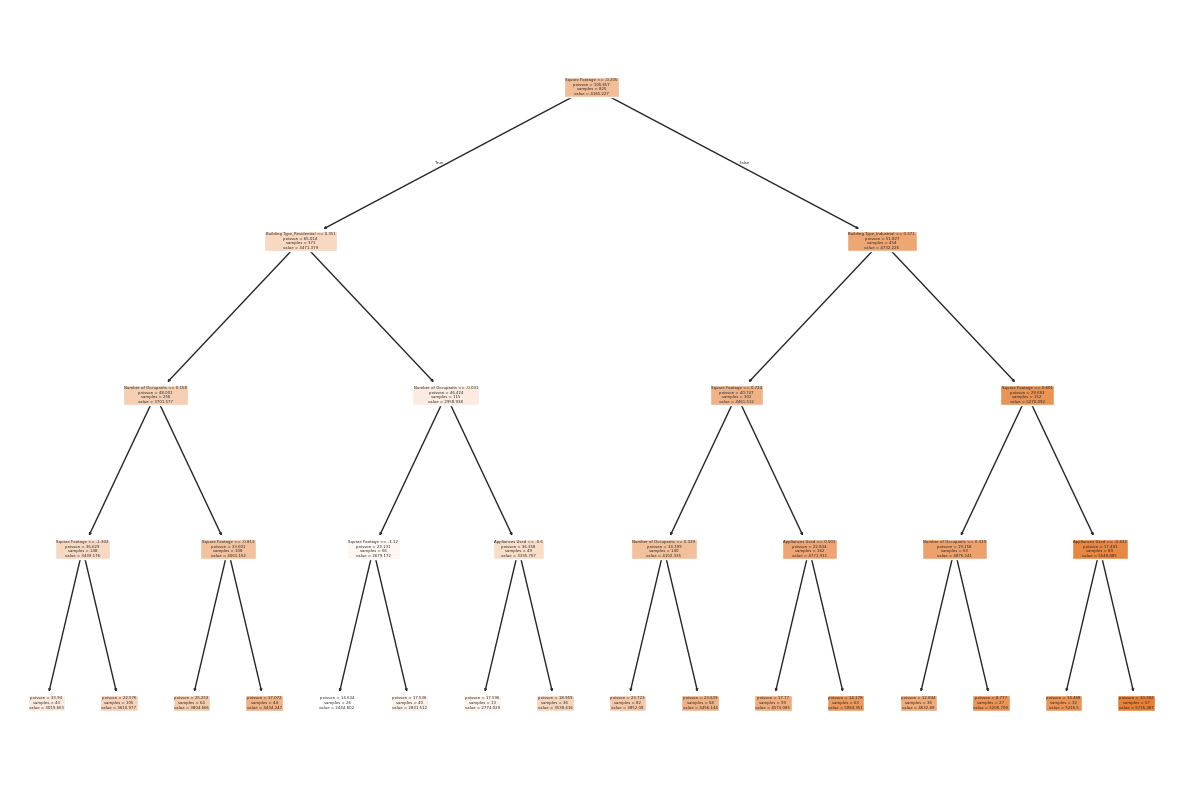

In [283]:
fig,axes = plt.subplots(figsize=(15,10))
tree.plot_tree(gridtree.best_estimator_,feature_names=X_train.columns,filled=True)

In [ ]:
# R2 düştü fakat karar ağacı daha anlaşılır bi hale geldi